# Практическая работа
## Тема: Градиентный спуск

---
### Задание
1.	Сгенерируйте датасет при помощи sklearn.datasets.make_regression. Если необходимо выполните масштабирование данных.
2.	Напишите самостоятельно функцию градиентного спуска (не стохастического), следуя приведенному ниже алгоритму:
1)	Инициализировать начальные веса и ε;
2)	Организовать цикл по количеству итераций;
3)	Расчет новых весов;
 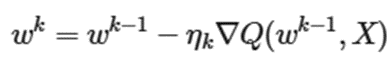
4)	Завершить цикл, если
 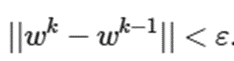

3.	Поэкспериментируйте со скоростью обучения. Сделайте выводы.
4.	Добавьте в функцию выбор случайного объекта на каждой итерации для нахождения весов, чтобы сделать функцию стохастического градиентного спуска.
5.	Обучите линейную модель при помощи градиентного и стохастического градиентного спуска. Нанесите среднеквадратичную ошибку для обоих методов на один график, сделайте выводы о разнице скорости сходимости каждого из методов.

---



In [ ]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

# 1. Generate the dataset using make_regression
# n_samples: number of samples
# n_features: number of features
# n_informative: number of informative features
# n_targets: number of regression targets
# random_state: seed for reproducibility
X, y = make_regression(n_samples=1000, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=42)

print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")

# Scale the data
# Initialize StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit and transform X (features)
X_scaled = scaler_X.fit_transform(X)

# Reshape y to be 2D for scaler, then fit and transform
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

print(f"Scaled X shape: {X_scaled.shape}")
print(f"Scaled y shape: {y_scaled.shape}")


Original X shape: (1000, 1)
Original y shape: (1000,)
Scaled X shape: (1000, 1)
Scaled y shape: (1000, 1)


### Определение скорости обучения

Определил несколько различных значений скорости обучения (learning rates) для тестирования.


In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
print("Defined learning rates:", learning_rates)

Defined learning rates: [0.001, 0.01, 0.1, 0.5]


### Запуск пакетной обработки градиентного спуска с различными скоростями обучения

Запустил реализованную функцию пакетного градиентного спуска с каждым из определенных значений скорости обучения и сохранил историю среднеквадратичной ошибки (MSE) для каждой попытки.


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

def batch_gradient_descent(X, y, learning_rate, n_iterations, epsilon=1e-6):
    # Add a bias term (intercept) to X
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # Initialize weights randomly
    # Number of features + 1 for the bias term
    weights = np.random.randn(X_b.shape[1], 1)

    mse_history = []

    for iteration in range(n_iterations):
        # Calculate predictions
        y_pred = X_b.dot(weights)

        # Calculate the gradient of the MSE with respect to weights
        # Gradient = (2/m) * X_b_T * (X_b * weights - y)
        gradient = (2/len(y)) * X_b.T.dot(y_pred - y.reshape(-1, 1))

        # Store old weights for convergence check
        old_weights = weights.copy()

        # Update weights
        weights = weights - learning_rate * gradient

        # Calculate MSE for the current iteration and store it
        mse = mean_squared_error(y, y_pred)
        mse_history.append(mse)

        # Check for convergence
        if np.linalg.norm(weights - old_weights) < epsilon:
            print(f"Converged after {iteration + 1} iterations for learning rate {learning_rate}")
            break

    return weights, mse_history

Функция batch_gradient_descent определена, теперь будет проходить итерация по заранее заданным learning_rates, вызов функции с X_scaled и сохранение полученной истории MSE в словаре.


In [ ]:
mse_histories = {}
n_iterations = 1000

for lr in learning_rates:
    print(f"Starting training with learning rate: {lr}")
    # Reshape y to be a 2D array if it's 1D, as expected by the batch_gradient_descent function
    _, current_mse_history = batch_gradient_descent(X_scaled, y.reshape(-1, 1), lr, n_iterations)
    mse_histories[lr] = current_mse_history
    print(f"Finished training with learning rate: {lr}. Last MSE: {current_mse_history[-1]:.4f}")

print("\nMSE histories collected for all learning rates.")

Starting training with learning rate: 0.001
Finished training with learning rate: 0.001. Last MSE: 397.2881
Starting training with learning rate: 0.01
Converged after 629 iterations for learning rate 0.01
Finished training with learning rate: 0.01. Last MSE: 392.0723
Starting training with learning rate: 0.1
Converged after 68 iterations for learning rate 0.1
Finished training with learning rate: 0.1. Last MSE: 392.0723
Starting training with learning rate: 0.5
Converged after 2 iterations for learning rate 0.5
Finished training with learning rate: 0.5. Last MSE: 392.0723
MSE histories collected for all learning rates.


Следующий этап заключается в построении графика изменения MSE по итерациям для всех скоростей обучения на одном графике. Это позволит визуально сравнить их сходимость.



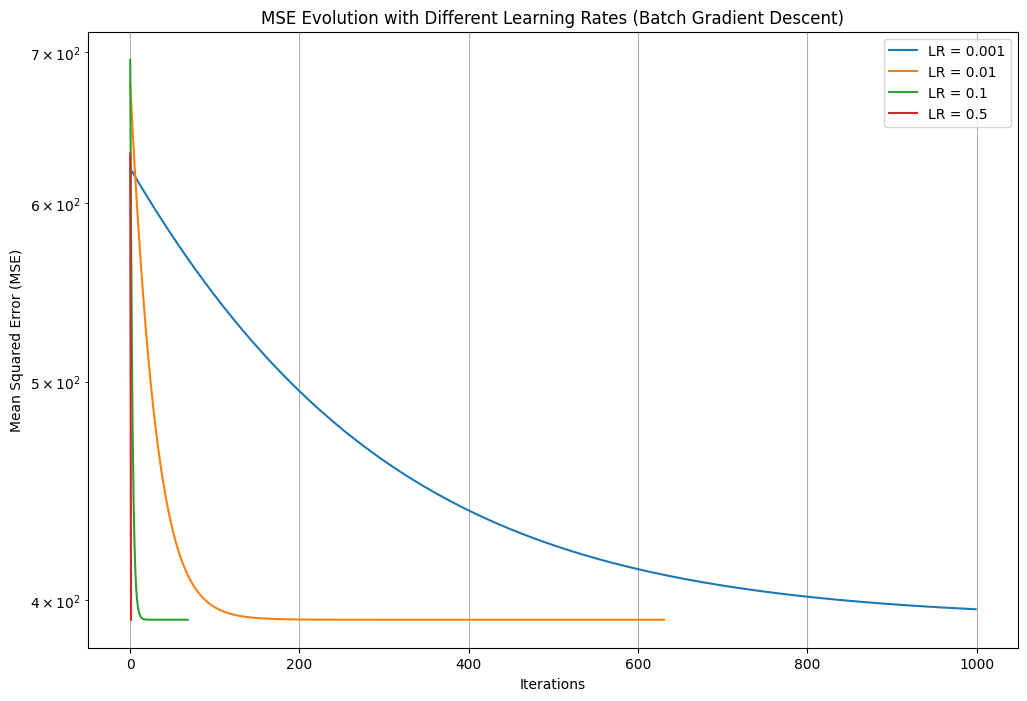

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for lr, history in mse_histories.items():
    plt.plot(history, label=f'LR = {lr}')

plt.title('MSE Evolution with Different Learning Rates (Batch Gradient Descent)')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.yscale('log') # Use a logarithmic scale for better visualization of differences
plt.legend()
plt.grid(True)
plt.show()

Следующий этап заключается в добавлении в функцию выбор случайного объекта на каждой итерации для нахождения весов, чтобы сделать функцию стохастического градиентного спуска.
Обучить линейную модель при помощи градиентного и стохастического градиентного спуска. Нанести среднеквадратичную ошибку для обоих методов на один график, сделать выводы о разнице скорости сходимости каждого из методов.


In [ ]:
def stochastic_gradient_descent(X, y, learning_rate, n_iterations, epsilon=1e-6):
    # Add a bias term (intercept) to X
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # Initialize weights randomly
    weights = np.random.randn(X_b.shape[1], 1)

    mse_history = []

    for iteration in range(n_iterations):
        # Select a random data point (or a small batch for mini-batch GD, but the task specifies 'random object')
        random_index = np.random.randint(0, len(y))
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]

        # Calculate prediction for the selected sample
        y_pred_i = xi.dot(weights)

        # Calculate the gradient using only this one sample
        # Gradient = 2 * xi_T * (xi * weights - yi)
        gradient = 2 * xi.T.dot(y_pred_i - yi.reshape(-1, 1))

        # Store old weights for convergence check
        old_weights = weights.copy()

        # Update weights
        weights = weights - learning_rate * gradient

        # Calculate MSE for the current state using the *entire* dataset for a meaningful comparison
        # In practice, for SGD, MSE might be evaluated less frequently or smoothed
        full_y_pred = X_b.dot(weights)
        mse = mean_squared_error(y, full_y_pred)
        mse_history.append(mse)

        # Check for convergence - this check can be noisy for SGD, but we keep it consistent for comparison
        if np.linalg.norm(weights - old_weights) < epsilon:
            print(f"Converged after {iteration + 1} iterations for learning rate {learning_rate}")
            break

    return weights, mse_history

In [ ]:
sgd_mse_histories = {}
# Using a learning rate that worked well for batch GD as a starting point
# SGD often benefits from different learning rates, but for initial comparison, this is fine.
learning_rate_sgd = 0.01
n_iterations_sgd = 10000 # SGD typically requires more iterations due to noisy updates

print(f"Starting training with Stochastic Gradient Descent (SGD) with learning rate: {learning_rate_sgd}")
_, sgd_current_mse_history = stochastic_gradient_descent(X_scaled, y.reshape(-1, 1), learning_rate_sgd, n_iterations_sgd)
sgd_mse_histories[learning_rate_sgd] = sgd_current_mse_history
print(f"Finished training with SGD. Last MSE: {sgd_current_mse_history[-1]:.4f}")

print("MSE history collected for SGD.")

Starting training with Stochastic Gradient Descent (SGD) with learning rate: 0.01
Finished training with SGD. Last MSE: 395.5723
MSE history collected for SGD.


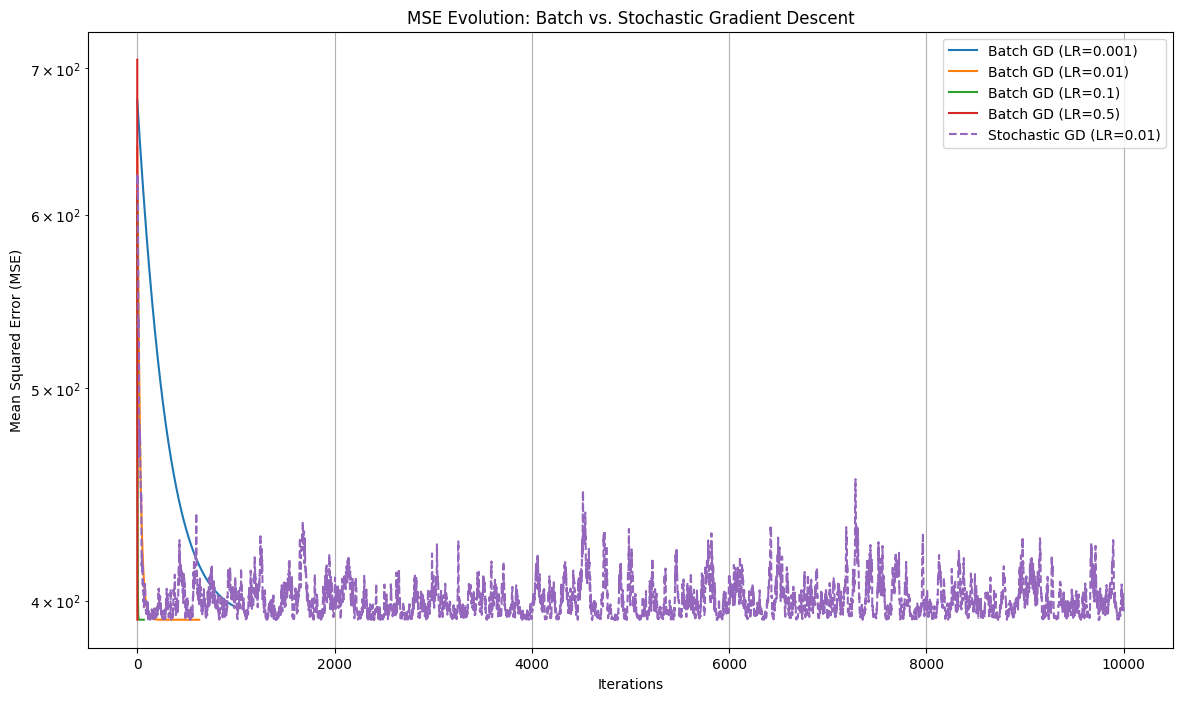

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

# Plot Batch Gradient Descent MSE histories
for lr, history in mse_histories.items():
    plt.plot(history, label=f'Batch GD (LR={lr})')

# Plot Stochastic Gradient Descent MSE history
for lr_sgd, history_sgd in sgd_mse_histories.items():
    plt.plot(history_sgd, label=f'Stochastic GD (LR={lr_sgd})', linestyle='--')

plt.title('MSE Evolution: Batch vs. Stochastic Gradient Descent')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.yscale('log') # Use a logarithmic scale for better visualization of differences
plt.legend()
plt.grid(True)
plt.show()

# Выводы
В **пакетном градиентном спуске (BGD)** один шаг очень медленный, так как нужно просуммировать градиенты по всем данным. Однако направление шага точное. Для больших датасетов (миллионы строк) один шаг может занимать слишком много времени, делая обучение непрактичным.

Движется по гладкой, стабильной траектории. Функция потерь уменьшается монотонно (при правильном learning rate).


---


В **стохастическом градиентном спуске (SGD)** один шаг очень быстрый, так как вычисляется только для одного объекта. Направление шага шумное (может указывать не точно в сторону минимума). Алгоритм начинает улучшать модель почти мгновенно, не дожидаясь обработки всего датасета.

Движется по дрожащей траектории. Из-за того, что каждый пример дает разную оценку градиента, функция потерь может временно возрастать, даже если в целом тренд на снижение.